In [ ]:
import sys
sys.path.append('./pyvisgraph')
from pyvisgraph.graph import Graph, Edge, Point
from pyvisgraph.vis_graph import VisGraph
from pyvisgraph.visible_vertices import visible_vertices
from pyvisgraph.graph import Graph, Edge
from pyvisgraph.shortest_path import shortest_path
from pyvisgraph.visible_vertices import visible_vertices, point_in_polygon
from pyvisgraph.visible_vertices import closest_point
from shapely.geometry import Point as sPoint
from shapely.geometry.polygon import Polygon as sPolygon
import random
import numpy as np

np.random.seed(1)
## 1. Generate a random polygon

polys = [
    
    [Point(6.0, 4.0), Point(6.5, 4.0), Point(7.0, 7.5),
     Point(9.0, 7.5), Point(9.5, 8.0), Point(6.5, 8.0)],
    
    [Point(1.25, 5.0), Point(2.0, 5.0), Point(2.5, 10.0),
     Point(3.1, 10.0), Point(2.5, 4.0), Point(1.0, 4.0)], 
     
    #  [Point(4, 7), Point(4, 4), Point(6, 4), Point(6, 7),
    #  Point(5.5, 7), Point(5.5, 5.5), Point(4.5, 5.5), Point(4.5, 7)],
    [
    Point(4.5, 2),     # Top left
    Point(6.5, 2),     # Top right
    Point(6.5, -1),     # Bottom right
    Point(6.0, -1),   # Indentation start (moving right)
    Point(6.0, 1.0), # Up into the notch
    Point(5.0, 1.0), # Across the notch
    Point(5.0, -1),   # Down back to the indentation bottom
    Point(4.5, -1)      # Bottom left
],
    
    # New non-convex polygon
    # [Point(8, 3), Point(10, 3), Point(10, 5), Point(9, 4), Point(8, 5)]
]

u_shaped_polygon = sPolygon([
    (4, 2),     # Top left
    (6, 2),     # Top right
    (6, -1),     # Bottom right
    (5.5, -1),   # Indentation start (moving right)
    (5.5,1.0), # Up into the notch
    (4.5, 1.0), # Across the notch
    (4.5, -1),   # Down back to the indentation bottom
    (4, -1)      # Bottom left
])

# Non-convex polygon
non_convex_polygon = sPolygon([
    (8, 3),   # Bottom left
    (10, 3),  # Bottom right
    (10, 5),  # Top right
    (9, 4),   # Indented point (creates concavity)
    (8, 5)    # Top left
])

polys_shapely = [sPolygon([(point.x, point.y) for point in poly]) for poly in polys]


## 2. Find out if a point is inside the polygon
def point_in_any_polygon(point, polys_shapely):
    for polygon in polys_shapely:
        if polygon.contains(point):
            return True
    return False

## 3. Generate a visibility graph
# Create a copy of polys_shapely with the notch removed from the U-shaped polygon
polys_removed = [
    
    [Point(6.0, 4.0), Point(6.5, 4.0),# Point(7.0, 7.5),
     Point(9.0, 7.5), Point(9.5, 8.0), Point(6.5, 8.0)],
    
    [Point(1.25, 5.0), #Point(2.0, 5.0), 
     Point(2.5, 10.0),
     Point(3.1, 10.0), Point(2.5, 4.0), Point(1.0, 4.0)], 
     
    #  [Point(4, 7), Point(4, 4), Point(6, 4), Point(6, 7),
    #  Point(5.5, 7), Point(5.5, 5.5), Point(4.5, 5.5), Point(4.5, 7)],
    [
    Point(4.5, 2),     # Top left
    Point(6.5, 2),     # Top right
    Point(6.5, -1),     # Bottom right
    Point(6.0, -1),   # Indentation start (moving right)
    # Point(5.5, 0.5), # Up into the notch
    # Point(4.5, 0.5), # Across the notch
    Point(5.0, -1),   # Down back to the indentation bottom
    Point(4.5, -1)      # Bottom left
]]
g = VisGraph()
g.build(polys_removed)

## 4. Generate random points
sigma = 0.5

means= np.array([[4,0],[8,2],[7,6],[2,8]]) # for rrt comparison

random_points = []

# Rotation angle (tilt) in degrees
tilt_angle_degrees = [0,0,0,0]
tilt_angle_radians = np.deg2rad(tilt_angle_degrees)

# Function to rotate (tilt) a point around the origin (0, 0)
def rotate_point(point, angle_rad):
    x, y = point.x, point.y
    x_rot = x * np.cos(angle_rad) - y * np.sin(angle_rad)
    y_rot = x * np.sin(angle_rad) + y * np.cos(angle_rad)
    return sPoint(x_rot, y_rot)

# Generate points for each mean
counter3  = 0
for mean in means:
    for _ in range(60):
        x = np.random.normal(loc=mean[0], scale=1.8)
        y = np.random.normal(loc=mean[1], scale=0.3)
        point = sPoint(x, y)
        tilted_point = rotate_point(point, tilt_angle_radians[counter3])
        if not point_in_any_polygon(tilted_point, polys_shapely):
            
            random_points.append(Point(tilted_point.x, tilted_point.y))
    counter3 = counter3+1
random_points_npy = np.array([[point.x, point.y] for point in random_points])
## 5. Find visible vertices and add edges to the visibility graph
# for p in random_points:
#     for v in g.find_visible(p):
#         g.visgraph.add_edge(Edge(p, v))

points_dummy = random_points.copy()
## 6. Find shortest path between every pair of points
# store all the 
# final_points = list(g.visgraph.graph.keys())
final_points = random_points
## 7. find pairwise distance between all points
# create an n*n matrix to store the distances as numpy array


def pairwise_distance(final_points,g):
    distances = np.zeros((len(final_points),len(final_points)))
    for i in range(len(final_points)):
        for j in range(len(final_points)):
            start = final_points[i]
            end = final_points[j]
            path,cost = g.shortest_path(start, end)
            distances[i][j] = cost
    return distances


  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 153.49it/s]


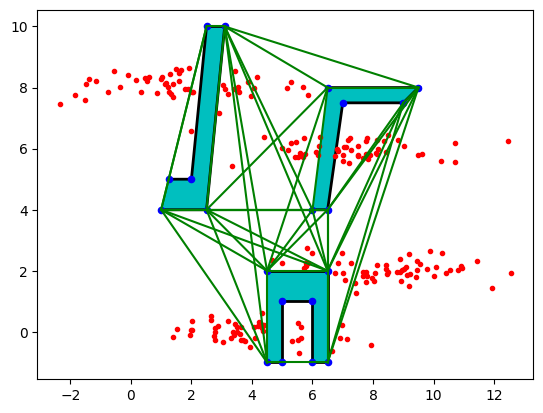

In [10]:
import matplotlib.pyplot as plt
from matplotlib.path import Path
import matplotlib.patches as patches

fig = plt.figure()
ax = fig.add_subplot(111)

################################# PLOT POLYGON #######################################
for poly in polys:
    path = Path([[p.x,p.y] for p in poly])
    patch = patches.PathPatch(path, facecolor='c', lw=2)
    ax.add_patch(patch)

# exemplars = [1,2,3]
for edge in g.visgraph.edges:
    ax.plot([edge.p1.x, edge.p2.x], [edge.p1.y, edge.p2.y], 'g-')
# scatter points for visibility graph vertices

# scatter points for original vertices
for poly in polys:

    ax.scatter([p.x for p in poly], [p.y for p in poly], c='b', s=20)


ax.scatter(random_points_npy[:,0], random_points_npy[:,1], color='red', marker='.', label='Target Points')# Plot the obstacles


In [ ]:
import numpy as np
from pyvisgraph.graph import Graph, Edge, Point
from sklearn.neighbors import NearestNeighbors
from scipy.spatial import KDTree
from sklearn.neighbors import BallTree
# 
np.random.seed(1)


size_grid = 11
candidate_exemplars = np.meshgrid(np.arange(-2,size_grid,3), np.arange(-2,size_grid,2))
# convert mesh_grid to list of coordinates
candidate_exemplars = np.vstack(list(map(np.ravel, candidate_exemplars))).T
candidate_exemplars = candidate_exemplars + random.uniform(0, 0.5)
final_candidate_exemplars = []
# convert to list of shapely points
for x,y in candidate_exemplars:
    point = sPoint(x, y)
    if point_in_any_polygon(point, polys_shapely) == False:
        final_candidate_exemplars.append(Point(point.x, point.y))



# make a copy of final_points and add exemplars to create a visibility graph
# final_points_with_exemplars = final_points.copy()
for x in final_candidate_exemplars:
    # x.x = x.x 
    # x.y = x.y 
    final_points.append(x)

# calculate the distance from every node to final_candidate_exemplars
# for p in final_points:
#     for v in g.find_visible(p):
#         g.visgraph.add_edge(Edge(p, v))


print(len(final_points))
################################## Visibility graph distance measure ########################################

def pairwise_distance(final_points,g):
    distances = np.zeros((len(final_points),len(final_points)))
    completed_iterations = 0
    for i in range(len(final_points)):
        for j in range(len(final_points)):
            start = final_points[i]
            end = final_points[j]
            path,cost = g.shortest_path(start, end)
            distances[i][j] = cost
        completed_iterations += 1
        print(f'Progress: {completed_iterations}')
    return distances

distances = pairwise_distance(final_points,g)


################################## Euclidean Measure ########################################
# def pairwise_distance(final_points):
#     distances = np.zeros((len(final_points), len(final_points)))
#     completed_iterations = 0

#     for i in range(len(final_points)):
#         for j in range(len(final_points)):
#             start = np.array(final_points[i])
#             end = np.array(final_points[j])
#             # Calculate Euclidean distance
#             cost = np.linalg.norm(start - end)
#             distances[i][j] = cost

#         completed_iterations += 1
#         print(f'Progress: {completed_iterations}/{len(final_points)}')
    
#     return distances

# final_points_npy = np.array([[point.x, point.y] for point in final_points])

# distances = pairwise_distance(final_points_npy)


# Truncating the distance 
# distances = np.log(1+distances)

distances[distances > 2] = 1e6 



243
Progress: 1
Progress: 2
Progress: 3
Progress: 4
Progress: 5
Progress: 6
Progress: 7
Progress: 8
Progress: 9
Progress: 10
Progress: 11
Progress: 12
Progress: 13
Progress: 14
Progress: 15
Progress: 16
Progress: 17
Progress: 18
Progress: 19
Progress: 20
Progress: 21
Progress: 22
Progress: 23
Progress: 24
Progress: 25
Progress: 26
Progress: 27
Progress: 28
Progress: 29
Progress: 30
Progress: 31
Progress: 32
Progress: 33
Progress: 34
Progress: 35
Progress: 36
Progress: 37
Progress: 38
Progress: 39
Progress: 40
Progress: 41
Progress: 42
Progress: 43
Progress: 44
Progress: 45
Progress: 46
Progress: 47
Progress: 48
Progress: 49
Progress: 50
Progress: 51
Progress: 52
Progress: 53
Progress: 54
Progress: 55
Progress: 56
Progress: 57
Progress: 58
Progress: 59
Progress: 60
Progress: 61
Progress: 62
Progress: 63
Progress: 64
Progress: 65
Progress: 66
Progress: 67
Progress: 68
Progress: 69
Progress: 70
Progress: 71
Progress: 72
Progress: 73
Progress: 74
Progress: 75
Progress: 76
Progress: 77
Prog

In [ ]:
print(len(final_candidate_exemplars))

extracted_distances = distances[-len(final_candidate_exemplars):, :len(final_points)-len(final_candidate_exemplars)]
distance_loaded = extracted_distances
print(type(distance_loaded))
distance_loaded = distance_loaded.tolist()
print(type(distance_loaded))

######################## Function to pick Exemplars################################



exemplars = []

def greedy_exemplar_clustering(budget,distance_loaded,final_candidate_exemplars):
    # size of mesh grid 
    distances2 = np.array(distance_loaded.copy())

    while budget > 0:

        # Find the other exemplars
        best_node = None
        # find the pairwise_distance between other final_candiate exemplars and final

        min_val = np.min(distances2) # get min value before removing infinity
        mask = np.isinf(distances2)
        distances2[mask] = 0
        max_val = np.max(distances2)
        total_distance = np.sum(distances2,axis=1)
        total_distance = total_distance.reshape(-1, 1)

        min_val = np.inf
        

        for iter in range(len(final_candidate_exemplars)):
            if iter in exemplars:
                continue
            # if total_distances_final_normalized[iter] < min_val and total_distances_final_normalized[iter] != 0 and total_distances_final_normalized[iter] > 100:
            if total_distance[iter] < min_val:
                min_val = total_distance[iter]
                best_node = iter
            fixed_row_index = best_node  # Example index for the fixed row
        
        for iter in range(len(final_candidate_exemplars)):
            if iter in exemplars:
                continue
                # Select the fixed row and the row to update
            fixed_row = distances2[fixed_row_index]
            row_to_update = distances2[iter]

            # Compare and update the row_to_update if the fixed row has smaller values
            distances2[iter] = np.minimum(fixed_row, row_to_update)
        exemplars.append(best_node)

        

        


        budget -= 1



    return exemplars

budget = 6  # Example budget
print(len(distance_loaded))
exemplars = greedy_exemplar_clustering(budget, distance_loaded, final_candidate_exemplars)
print(exemplars)

34
[[1.00000000e+06 1.00000000e+06 1.00000000e+06 ... 1.00000000e+06
  1.00000000e+06 1.00000000e+06]
 [1.00000000e+06 1.00000000e+06 1.00000000e+06 ... 1.00000000e+06
  1.00000000e+06 1.00000000e+06]
 [1.00000000e+06 1.86887744e+00 1.73102175e+00 ... 1.00000000e+06
  1.00000000e+06 1.00000000e+06]
 ...
 [1.00000000e+06 1.00000000e+06 1.00000000e+06 ... 1.00000000e+06
  1.00000000e+06 1.00000000e+06]
 [1.00000000e+06 1.00000000e+06 1.00000000e+06 ... 1.00000000e+06
  1.00000000e+06 1.00000000e+06]
 [1.00000000e+06 1.00000000e+06 1.00000000e+06 ... 1.00000000e+06
  1.00000000e+06 1.00000000e+06]]
<class 'numpy.ndarray'>
<class 'list'>
34
[13, 7, 25, 21, 22, 14]


(35, 2)


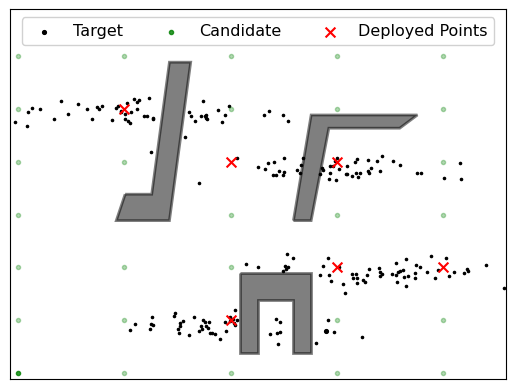

In [97]:
import matplotlib.pyplot as plt
from matplotlib.path import Path
import matplotlib.patches as patches

fig = plt.figure()
ax = fig.add_subplot(111)

################################# PLOT POLYGON #######################################
for poly in polys:
    poly.append(poly[0])  # Ensure the polygon is closed by repeating the first point

    path = Path([[p.x,p.y] for p in poly])
    patch = patches.PathPatch(path, facecolor='k', lw=2,alpha=0.5)
    ax.add_patch(patch)

# exemplars = [1,2,3]
# for edge in g.visgraph.edges:
#     ax.plot([edge.p1.x, edge.p2.x], [edge.p1.y, edge.p2.y], 'k-')
# scatter points for visibility graph vertices

# scatter points for original vertices
# for poly in polys:
#     ax.scatter([p.x for p in poly], [p.y for p in poly], c='k', s=10)
print(candidate_exemplars.shape)
################################## PLOT POINTS ############################################
# for i, points in enumerate(final_candidate_exemplars):
#     if i == 0:
#         ax.scatter(points.x, points.y, c='y', s=10, marker='*')
#     else:
#         ax.scatter(points.x, points.y, c='y', s=10, marker='*')

# # map.plotobs(ax)


ax.scatter(random_points_npy[:,0], random_points_npy[:,1], color='black', s=10, marker='.')
ax.scatter(random_points_npy[0,0], random_points_npy[0,1], color='black', s=30, marker='.', label='Target')


default_red = 0
default_green = 0

for index, iter in enumerate(final_candidate_exemplars):
    if index in exemplars:  # These are your final points
        ax.scatter(iter.x, iter.y, color='red', marker='x', s=50, 
                   label='Deployed Points' if default_red == 0 else '_nolegend_')
        default_red += 1
    else:
        ax.scatter(iter.x, iter.y, color='green', marker='.', 
                   label='Candidate' if default_green == 0 else '_nolegend_',alpha=0.8 if default_green == 0 else 0.3 )
        default_green += 1
# Display the plot
# Remove x and y labels
ax.set_xlim([-2, 12])  # Adjust as needed
ax.set_ylim([-2, 12])  # Adjust as needed
ax.set_xticks([])
ax.set_yticks([])
ax.legend(loc='upper center', framealpha=0.9,fontsize=11.5,ncols = 4)  
plt.show()

[Point(6.92, -0.18), Point(3.05, -0.32), Point(5.56, -0.69), Point(7.14, -0.23), Point(6.63, -0.62), Point(3.42, -0.12), Point(3.69, -0.26), Point(4.08, 0.17), Point(2.02, 0.34), Point(5.62, 0.15), Point(5.62, -0.21), Point(3.78, -0.28), Point(3.52, 0.16), Point(2.76, -0.12), Point(2.76, -0.25), Point(2.79, -0.00), Point(1.99, 0.07), Point(6.99, 0.22), Point(3.65, -0.27), Point(2.66, 0.51), Point(4.09, -0.19), Point(4.34, 0.63), Point(4.22, 0.19), Point(1.94, -0.10), Point(3.62, 0.18), Point(5.51, 0.28), Point(2.64, 0.38), Point(7.93, -0.42), Point(1.40, -0.15), Point(4.29, 0.26), Point(3.45, 0.25), Point(4.41, 0.23), Point(3.60, -0.06), Point(4.34, 0.12), Point(4.36, 0.04), Point(2.79, 0.11), Point(4.22, 0.34), Point(3.32, -0.19), Point(3.38, 0.01), Point(2.88, 0.21), Point(3.20, 0.37), Point(2.03, 0.05), Point(5.33, -0.29), Point(3.52, 0.01), Point(1.53, 0.09), Point(5.52, -0.26), Point(3.93, -0.48), Point(7.96, 1.77), Point(10.29, 2.59), Point(4.66, 2.37), Point(10.93, 2.10), Point(

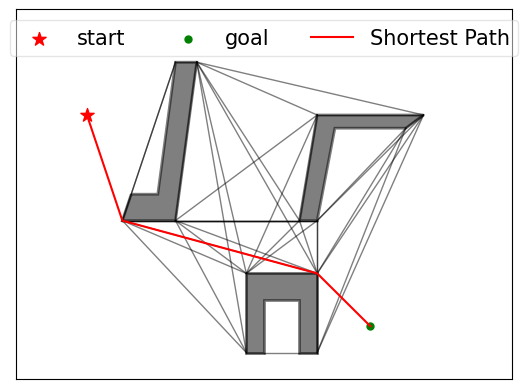

In [ ]:
#################################### VISIBILITY GRAPH PLOT FOR THE PAPER ########################################

fig = plt.figure()
ax = fig.add_subplot(111)

################################# PLOT POLYGON #######################################
for poly in polys:
    poly.append(poly[0])  # Ensure the polygon is closed by repeating the first point

    path = Path([[p.x,p.y] for p in poly])
    patch = patches.PathPatch(path, facecolor='k', lw=2,alpha=0.5)
    ax.add_patch(patch)

# exemplars = [1,2,3]
for edge in g.visgraph.edges:
    ax.plot([edge.p1.x, edge.p2.x], [edge.p1.y, edge.p2.y], 'k-',lw=1,alpha=0.5)
# scatter points for visibility graph vertices

# scatter points for original vertices
# for poly in polys:
#     ax.scatter([p.x for p in poly], [p.y for p in poly], c='k', s=10)

start = final_points[0]
end = final_points[10]
start = Point(0,8)
end = Point(8,0)
print(final_points)

path,cost = g.shortest_path(start, end)
x_coords = [point.x for point in path]
y_coords = [point.y for point in path]



# Plot the path as a red line (and add red markers)
ax.scatter(x_coords[0], y_coords[0], color='r',marker='*',s= 100, label = 'start')
ax.scatter(x_coords[-1], y_coords[-1], color='g',marker='.',s=100,label='goal')
ax.plot(x_coords, y_coords, 'r-', linewidth=1.5, label='Shortest Path')


ax.set_xlim([-2, 12])  # Adjust as needed
ax.set_ylim([-2, 12])  # Adjust as needed
ax.set_xticks([])
ax.set_yticks([])
ax.legend(loc='upper center', frameon= True, framealpha=0.5,fontsize=15,ncols = 3)  

plt.show()